# Problem 6 - Phase Identification(2)

## Agenda
- Problem Description
- Problem Implementation
- Wrap-Up

## Problem Description
- <b>Consider $N$ customers whose connection phase assumes one out of three possible labels $a$, $b$, or $c$ and estimate the correct customer-to-label assignment based on $M$ readings whose per-phase values are a function of the corresponding phase-connected individual customer reading.

Considered network
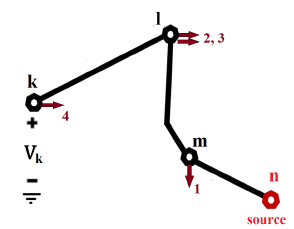

<b>Import Python Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [33]:
cosPhi=0.95
time=48
m=12
netFactor=0.25
noiseFactor=0.00

<b>Initial data

In [34]:
#Consumption dataset
s=  [[0.0450,    0.0150,    0.0470,    0.0330],
     [0.0250,    0.0150,    0.2480,    0.0330],
     [0.0970,    0.0250,    0.3940,    0.0330],
     [0.0700,    0.0490,    0.0200,    0.4850],
     [0.1250,    0.0460,    0.0160,    0.1430],
     [0.2900,    0.0270,    0.0160,    0.0470],
     [0.2590,    0.0150,    0.0170,    0.0200],
     [0.2590,    0.0160,    0.0280,    0.0160],
     [0.4420,    0.0160,    0.0500,    0.0170],
     [0.2010,    0.0230,    0.0460,    0.0160],
     [0.2060,    0.0490,    0.0220,    0.0240],
     [0.1300,    0.0470,    0.0160,    0.0490],
     [0.0460,    0.0260,    0.0170,    0.0480]]
s = np.array(s)

#topology
topo=[[1, 2],[2,3],[3,4]]
nBUS=np.max(topo)

#Impedance
z=np.multiply([complex(0.1,0.05),complex(0.15,0.07),complex(0.2,0.1)],netFactor)

vr=1 #Reference voltage
el=1
ni=20 #Iterations for the Power Flow




<b>Power Flow Function

In [35]:
def pf3ph(t,z,si,vr,el,ni,al):
    #Matrices creation
    t=np.array(t)
    p=t[:,0]
    f=t[:,1]
    w=len(p)+1
    vp=np.zeros((nBUS-1,w), dtype=complex)
    vn=np.zeros((nBUS-1,w), dtype=complex)
    vp[0,0:w]=vr
    
    for h in range (2,nBUS):
        vp[h-1,:]=vp[h-2,:]*al  #Create a three phase system of voltages
                                #Voltages will be the same in all BUS

    va=vp-vn                                                      #Auxiliar voltage
    ia=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))      #Auxiliar current 
    
    for it in range(ni):                                          #Iterations of Power Flow
        va=vp-vn
        ip=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))  #Phase current 
        inn=-np.sum(ip,0)                                         #Neutral current 
        for k in range(w-1,0,-1):                                 #Backward Cycle
            n=f[k-1]
            m=p[k-1]
            ip[:,m-1]=ip[:,m-1]+ip[:,n-1]                         #Phase Current
            inn=-np.sum(ip,0)                                     #Neutral Current

        eps= np.linalg.norm(np.max(np.abs(ia-ip),0))              #Error, comparing the new currents and the old ones (previous iteration)

        if eps>1e-4:
            ia=ip
            mvp=0
            mvn=0
            eps=np.inf
        else:                       #If the error is lower than the limit, we can return the results 
            mvp=(vp-vn)             #Phase Voltages to return
            mvn=vn[0,:]             #Neutral Voltage to return
#            return mvp, mvn, eps, ip, inn;
            return mvp;
        for k in range (w-1):                     #Forward Cycle
            n=f[k]                                
            m=p[k]
            vn[:,n-1]=vn[:,m-1]-z[k]*inn[n-1]     #Neutral Voltage 
            vp[:,n-1]=vp[:,m-1]-z[k]*ip[:,n-1]    #Phase Voltage
        ia=ip             #Save the current of previous iteration


<b> Compute the values of voltages obtained by PMUs

In [36]:
#Creation of Matrices
al=np.exp(np.multiply(np.multiply(complex(0,-1),2/3),np.pi)) #Phase Angle
Y=np.zeros((3*m), dtype=complex)
X=np.zeros((3*m,m), dtype=complex)
v=np.zeros((m,3))
dv_abs=np.zeros((m,3))


for i in range(m):
    si=[[0, 0, s[i,2], 0],[0, 0, s[i,1], 0],[0, s[i,0],  0, s[i,3]]] #Connection of consumers by
                                                                     #node and by phase
                                                                     #Consumer 1 (s[i,0]) is 
                                                                     #connected to Bus 2 in Phase 3
    mvp=pf3ph(topo,z,si,vr,el,ni,al)
    noise=1+noiseFactor*np.random.randn(3)
    mvp[:,3]=np.multiply(mvp[:,3],noise)                       #Add noise to the voltages
    Y[3*(i):3*(i)+3]=mvp[:,3]                                  #Save the voltages in matrix Y
    dv_abs[i,:]=vr-np.abs(mvp[:,3])                            #Volage variations (only to plot)

Volt=np.reshape(Y,(m,3))   

print ('The voltages measured in the PMUs are:\n',Volt)

The voltages measured in the PMUs are:
 [[ 0.99866484-0.00476962j -0.49831414-0.86835917j -0.49392011+0.85964588j]
 [ 0.97290228-0.01601085j -0.51139766-0.87380016j -0.50744349+0.85456696j]
 [ 0.95608633-0.02441701j -0.51885398-0.87750207j -0.51325967+0.84910673j]
 [ 1.04767033-0.03551787j -0.45091668-0.89757332j -0.40102796+0.79332501j]
 [ 1.01576499-0.00999985j -0.48302166-0.87236861j -0.46567302+0.84426734j]
 [ 1.00968654-0.00695356j -0.48918564-0.87063669j -0.47774451+0.85167455j]
 [ 1.00602188-0.005418j   -0.49284148-0.869901j   -0.48483326+0.85566688j]
 [ 1.00423842-0.00571336j -0.4939299 -0.86980129j -0.48633757+0.85598497j]
 [ 1.00578779-0.00995392j -0.4910006 -0.87340185j -0.4790803 +0.84942259j]
 [ 1.0006834 -0.00538471j -0.49631931-0.86845387j -0.49010362+0.8577634j ]
 [ 1.00475844-0.00282624j -0.4936193 -0.86480633j -0.48660002+0.8589564j ]
 [ 1.00631448-0.00319825j -0.49244873-0.86549546j -0.48460471+0.85781421j]]


<b> Sum of Impedences
    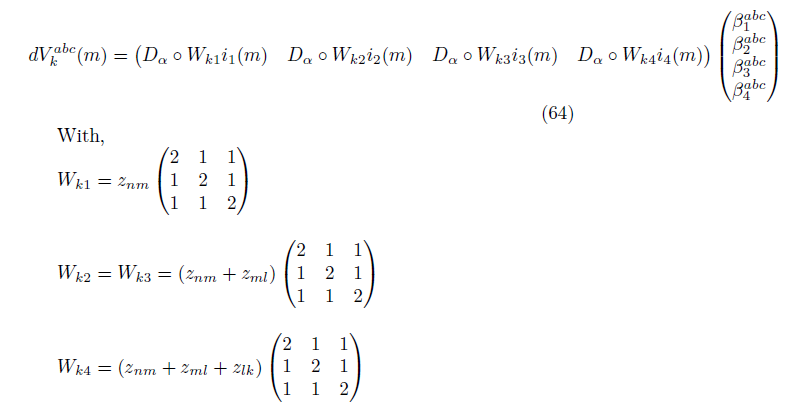

In [37]:
#The value of Z is the multiplication between D and W but not considering the values of z_nm;z_ml and zlk
Z=[[2, al, al**2],[1, 2*al, al**2],[1, al, 2*al**2]]


<b>Complex Expansion
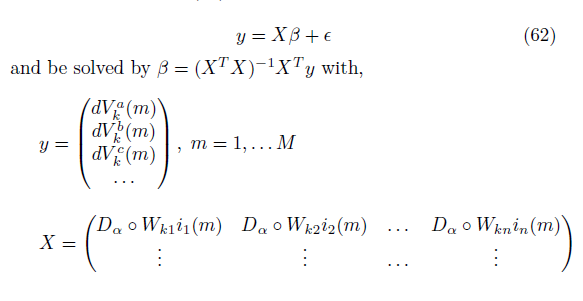

In [38]:
# Matrices Creation
vz = np.zeros(3*m, dtype=complex)
vz_abs = np.zeros(3*m, dtype=complex)

# Compute dVk for each time period m   
for i in range(m):
    # PMU (complex voltages)
    vz[3*i:3*i+3] = vr*np.array([1, al, al**2]) - Y[3*i:3*i+3]

    # RTU (only magnitudes)
    vz_abs[3*i:3*i+3] = (vr - np.abs(Y[3*i:3*i+3])) * np.array([1, al, al**2])


# ------------------------------------------------------------
#  BUILD X MATRIX  (3m × 12)
#  4 customers × 3 phases = 12 unknown betas
# ------------------------------------------------------------

X = np.zeros((3*m, 12), dtype=complex)

for i in range(m):
    X_block = np.zeros((3, 12), dtype=complex)

    for c in range(4):  # 4 consumers
        # Each consumer contributes a 3×3 block = Z * s[i,c]
        Z = np.array([[2, al, al**2],
              [1, 2*al, al**2],
              [1, al, 2*al**2]], dtype=complex)

        X_block[:, 3*c:3*(c+1)] = Z * s[i, c]

    X[3*i:3*i+3, :] = X_block


# ------------------------------------------------------------
#  REGRESSION: solve y = X β
# ------------------------------------------------------------

# Betas with PMUs info
Bpmu, *_ = np.linalg.lstsq(X, vz, rcond=None)

# Betas with RTUs info
Brtu, *_ = np.linalg.lstsq(X, vz_abs, rcond=None)


# ------------------------------------------------------------
#  RESHAPE BETAS INTO (4 customers × 3 phases)
# ------------------------------------------------------------

BBpmu = Bpmu.reshape(4, 3)
BBrtu = Brtu.reshape(4, 3)


# ------------------------------------------------------------
#  CONVERT TO BINARY PHASE LABELS
# ------------------------------------------------------------

def to_binary_labels(B):
    BB = np.zeros_like(B, dtype=int)
    for i in range(B.shape[0]):
        k = np.argmax(np.real(B[i, :]))   # choose phase with largest real part
        BB[i, k] = 1
    return BB

BBpmu_bin = to_binary_labels(BBpmu)
BBrtu_bin = to_binary_labels(BBrtu)


# ------------------------------------------------------------
#  PRINT RESULTS
# ------------------------------------------------------------

print('Betas (complex) considering information from PMUs:\n', Bpmu, '\n')
print('Betas (complex) considering information from RTUs:\n', Brtu, '\n')

print('Betas organized (customer × phase) PMUs:\n', BBpmu, '\n')
print('Betas organized (customer × phase) RTUs:\n', BBrtu, '\n')

print('Binary phase labels (PMUs):\n', BBpmu_bin, '\n')
print('Binary phase labels (RTUs):\n', BBrtu_bin, '\n')


Betas (complex) considering information from PMUs:
 [-3.13266200e-05+6.79589395e-05j -1.06608093e-05+2.18806848e-05j
  2.51598753e-02+1.21686542e-02j -1.87707107e-04+4.01524765e-04j
  6.25000727e-02+3.00103847e-02j -3.48618490e-03+7.77170725e-03j
  6.31511373e-02+2.86031037e-02j  3.23783029e-05-6.78030351e-05j
 -2.36388641e-04+4.86241992e-04j  1.68250058e-05-3.56869990e-05j
 -9.72493160e-05+1.93911431e-04j  1.15654803e-01+4.80622739e-02j] 

Betas (complex) considering information from RTUs:
 [-0.01139912-0.01138399j  0.00168309+0.0159158j   0.03454583-0.00453181j
  0.00321253+0.0430265j   0.09481318-0.0112951j  -0.02939363-0.0317314j
  0.08601069-0.01043496j -0.02709938-0.02874752j  0.00302374+0.03918248j
 -0.04943624-0.05376477j  0.00078745+0.07116277j  0.15599298-0.017398j  ] 

Betas organized (customer × phase) PMUs:
 [[-3.13266200e-05+6.79589395e-05j -1.06608093e-05+2.18806848e-05j
   2.51598753e-02+1.21686542e-02j]
 [-1.87707107e-04+4.01524765e-04j  6.25000727e-02+3.00103847e-02j


<b>Graphics

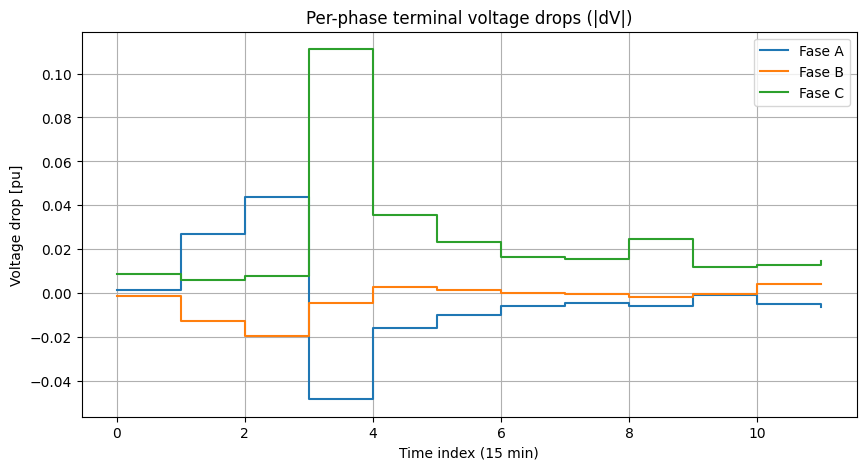

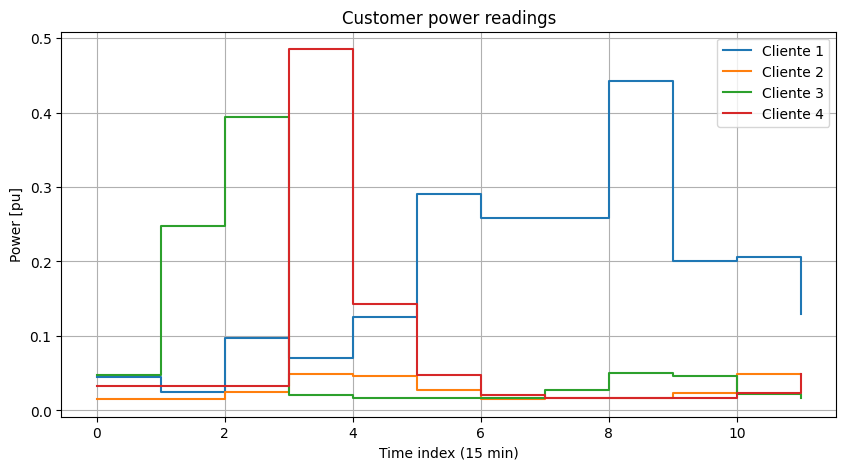

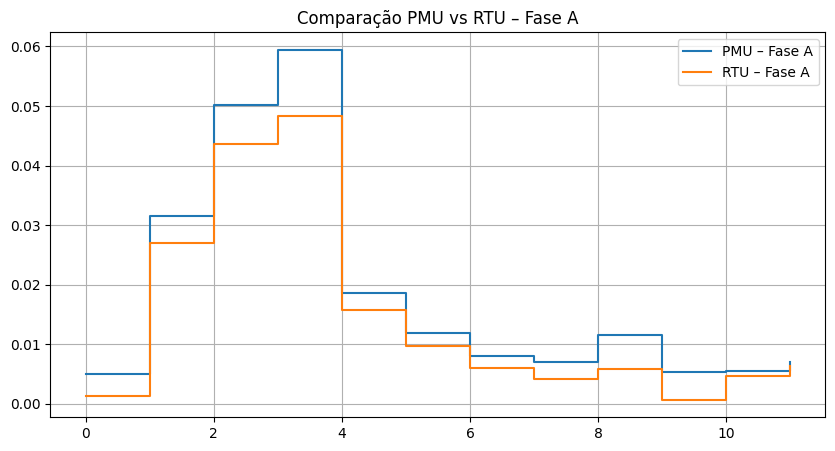

In [44]:
# ------------------------------------------------------------
# 1) Determinar o número REAL de amostras do power flow
# ------------------------------------------------------------

m_pf = dv_abs.shape[0]     # deve ser 12
x = np.arange(m_pf)


# ------------------------------------------------------------
# 2) Gráfico das quedas de tensão por fase (step)
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.step(x, dv_abs[:,0], where='post', label='Fase A')
plt.step(x, dv_abs[:,1], where='post', label='Fase B')
plt.step(x, dv_abs[:,2], where='post', label='Fase C')

plt.title('Per-phase terminal voltage drops (|dV|)')
plt.xlabel('Time index (15 min)')
plt.ylabel('Voltage drop [pu]')
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 3) Gráfico dos consumos dos clientes (step)
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.step(x, s[:m_pf,0], where='post', label='Cliente 1')
plt.step(x, s[:m_pf,1], where='post', label='Cliente 2')
plt.step(x, s[:m_pf,2], where='post', label='Cliente 3')
plt.step(x, s[:m_pf,3], where='post', label='Cliente 4')

plt.title('Customer power readings')
plt.xlabel('Time index (15 min)')
plt.ylabel('Power [pu]')
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.step(x, np.abs(vz[0::3]), where='post', label='PMU – Fase A')
plt.step(x, np.abs(vz_abs[0::3]), where='post', label='RTU – Fase A')
plt.title('Comparação PMU vs RTU – Fase A')
plt.grid(True)
plt.legend()
plt.show()



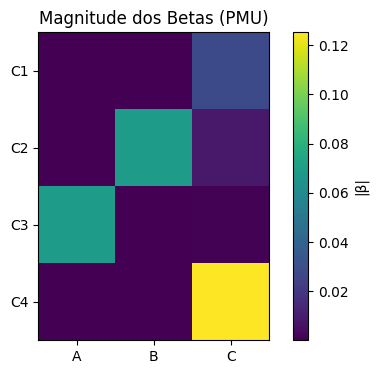

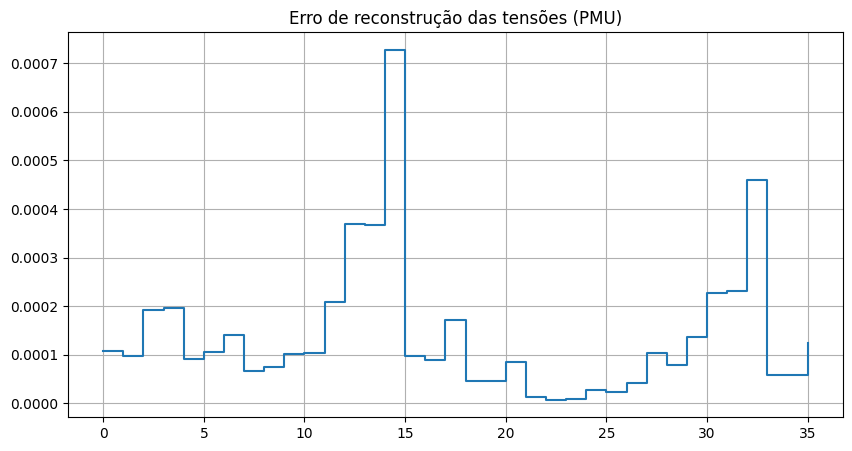

Cliente 1: fase estimada = 2
Cliente 2: fase estimada = 1
Cliente 3: fase estimada = 0
Cliente 4: fase estimada = 2


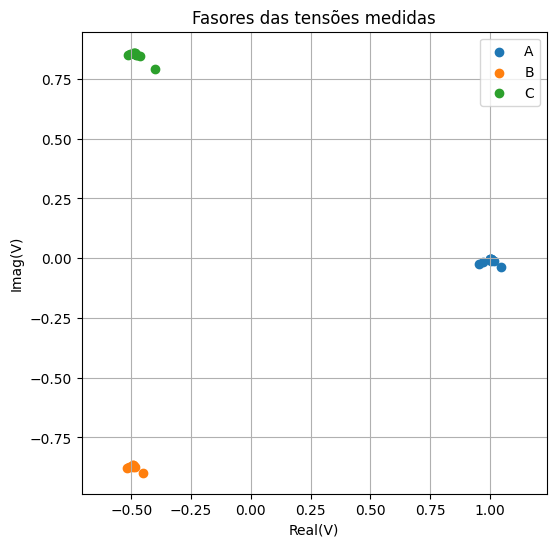

In [48]:
plt.figure(figsize=(6,4))
plt.imshow(np.abs(BBpmu), cmap='viridis')
plt.colorbar(label='|β|')
plt.xticks([0,1,2], ['A','B','C'])
plt.yticks([0,1,2,3], ['C1','C2','C3','C4'])
plt.title('Magnitude dos Betas (PMU)')
plt.show()

V_est = X @ Bpmu
err = np.abs(V_est - vz)

plt.figure(figsize=(10,5))
plt.step(range(len(err)), err.real, where='post')
plt.title('Erro de reconstrução das tensões (PMU)')
plt.grid(True)
plt.show()

for i in range(4):
    print(f"Cliente {i+1}: fase estimada = {np.argmax(np.abs(BBpmu[i]))}")

plt.figure(figsize=(6,6))
plt.scatter(Volt[:,0].real, Volt[:,0].imag, label='A')
plt.scatter(Volt[:,1].real, Volt[:,1].imag, label='B')
plt.scatter(Volt[:,2].real, Volt[:,2].imag, label='C')
plt.xlabel('Real(V)')
plt.ylabel('Imag(V)')
plt.title('Fasores das tensões medidas')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()


In [49]:
# ------------------------------------------------------------
# 1) Preparar correntes por fase (com base nas fases estimadas)
# ------------------------------------------------------------

# BBpmu é 4x3: cada linha = cliente, cada coluna = fase
# s é m x 4: consumos dos clientes
# Volt é m x 3: tensões complexas medidas

m_pf = Volt.shape[0]     # número real de amostras do PF
Iph = np.zeros((m_pf, 3), dtype=complex)   # correntes por fase

for t in range(m_pf):
    for cust in range(4):
        phase = np.argmax(np.abs(BBpmu[cust]))   # fase dominante
        Iph[t, phase] += s[t, cust]              # soma correntes por fase


# ------------------------------------------------------------
# 2) Calcular quedas de tensão ΔV = Vr - Vmedida
# ------------------------------------------------------------

# Vr é o vetor de tensões de referência (3x1)
dV = vr - Volt[:m_pf, :]


# ------------------------------------------------------------
# 3) Construir o sistema linear para estimar Z
#    ΔV = I * Z   →   empilhar tudo e resolver LS
# ------------------------------------------------------------

A = []
b = []

for t in range(m_pf):
    It = Iph[t, :]          # 3 correntes
    dVt = dV[t, :]          # 3 quedas de tensão

    # Cada amostra dá 3 equações:
    # dVa = ZaA*Ia + Zab*Ib + Zac*Ic
    # dVb = Zba*Ia + Zbb*Ib + Zbc*Ic
    # dVc = Zca*Ia + Zcb*Ib + Zcc*Ic

    A.append([It[0], It[1], It[2], 0,     0,     0,     0,     0,     0])
    A.append([0,     0,     0,     It[0], It[1], It[2], 0,     0,     0])
    A.append([0,     0,     0,     0,     0,     0,     It[0], It[1], It[2]])

    b.append(dVt[0])
    b.append(dVt[1])
    b.append(dVt[2])

A = np.array(A, dtype=complex)
b = np.array(b, dtype=complex)


# ------------------------------------------------------------
# 4) Resolver o problema de mínimos quadrados
# ------------------------------------------------------------

Zvec, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

# Reorganizar para matriz 3x3
Z_est = np.array([
    Zvec[0:3],
    Zvec[3:6],
    Zvec[6:9]
])

print("Matriz de impedâncias estimada Z (3x3):")
print(Z_est)


Matriz de impedâncias estimada Z (3x3):
[[ 0.13445621+5.00094179e-02j -0.11643641+8.54141654e-03j
  -0.04203612+3.07863284e-02j]
 [ 2.92218157+1.66740868e+00j 19.11045129+1.10425986e+01j
   2.29197251+1.37822740e+00j]
 [ 2.93053927-1.63183935e+00j 19.00424175-1.10180035e+01j
   2.2498311 -1.28603732e+00j]]


In [50]:
# ------------------------------------------------------------
# 1) Preparar o problema linear
# ------------------------------------------------------------
# A : matriz do modelo (n_equações × n_variáveis)
# b : vetor das medições (n_equações × 1)

A = A.astype(float)      # garantir que é real se necessário
b = b.astype(float)

# ------------------------------------------------------------
# 2) Solução minimum-norm (pseudoinversa direita)
#    x_mn = A^T (A A^T)^(-1) b
# ------------------------------------------------------------

# Evitar problemas numéricos com inversão direta
At = A.T
AA_t_inv = np.linalg.pinv(A @ At)   # inversa generalizada
x_mn = At @ (AA_t_inv @ b)

print("Solução minimum-norm:")
print(x_mn)


# ------------------------------------------------------------
# 3) Solução regularizada (Tikhonov / Ridge)
#    x_reg = (A^T A + λ I)^(-1) A^T b
# ------------------------------------------------------------

lambda_reg = 1e-9
I = np.eye(A.shape[1])

x_reg = np.linalg.solve(At @ A + lambda_reg * I, At @ b)

print("\nSolução regularizada (λ = 1e-9):")
print(x_reg)


# ------------------------------------------------------------
# 4) Comparação dos erros de ajuste
# ------------------------------------------------------------

# Erro residual: ||A x - b||
err_mn  = np.linalg.norm(A @ x_mn  - b)
err_reg = np.linalg.norm(A @ x_reg - b)

print("\nErro residual minimum-norm:", err_mn)
print("Erro residual regularizado :", err_reg)


# ------------------------------------------------------------
# 5) Comparação das normas das soluções
# ------------------------------------------------------------

norm_mn  = np.linalg.norm(x_mn)
norm_reg = np.linalg.norm(x_reg)

print("\nNorma da solução minimum-norm:", norm_mn)
print("Norma da solução regularizada :", norm_reg)


Solução minimum-norm:
[ 0.13445621 -0.11643641 -0.04203612  2.92218157 19.11045129  2.29197251
  2.93053927 19.00424175  2.2498311 ]

Solução regularizada (λ = 1e-9):
[ 0.13445621 -0.11643637 -0.04203612  2.92218177 19.11044529  2.29197303
  2.93053947 19.00423578  2.24983162]

Erro residual minimum-norm: 2.243858680817161
Erro residual regularizado : 2.2438586808172114

Norma da solução minimum-norm: 27.45625683114842
Norma da solução regularizada : 27.456248652193832


/tmp/ipykernel_15097/912171009.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  A = A.astype(float)      # garantir que é real se necessário
/tmp/ipykernel_15097/912171009.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  b = b.astype(float)


In [52]:
# ------------------------------------------------------------
# 1) Escolher o bus m onde tens medições adicionais
# ------------------------------------------------------------
# Para o laboratório, vamos assumir que o bus m é o bus 1 (cliente 1)
# Podes mudar para outro se quiseres.

bus_m = 0   # índice 0 → cliente 1


# ------------------------------------------------------------
# 2) Definir Vm_ref (pseudo-medida)
# ------------------------------------------------------------
# Vamos usar a média das tensões medidas no PF como pseudo-medida.
# Isto é exatamente o que o capítulo faz (médias de 4 períodos).

Vm_ref = np.mean(Volt[:, :], axis=0)   # vetor 3x1
Vm_ref = Vm_ref.astype(complex)


# ------------------------------------------------------------
# 3) Definir Vm_meas (medição real)
# ------------------------------------------------------------
# Aqui tens duas opções:
#   (A) usar a tensão real medida no instante final
#   (B) adicionar ruído para simular uma medição real

Vm_meas = Volt[-1, :]   # usar a última medição real
# Vm_meas = Volt[-1, :] * (1 + 0.01*np.random.randn(3))  # alternativa com ruído


# ------------------------------------------------------------
# 4) Construir ΔV_m = Vm_meas - Vm_ref
# ------------------------------------------------------------

DeltaV_m = Vm_meas - Vm_ref


# ------------------------------------------------------------
# 5) Construir Wm (modelo aproximado)
# ------------------------------------------------------------
# O capítulo usa a linha correspondente de Wk1 (matriz W do bus k)
# Para simplificar, vamos usar a mesma aproximação linear:
# Δ|V| ≈ Re{ conj(Vref)/|Vref| * ΔV }

Wm = np.zeros((3, A.shape[1]), dtype=complex)

for ph in range(3):
    # fator de projeção (modelo aproximado de Carvalho et al.)
    proj = np.conj(Vm_ref[ph]) / np.abs(Vm_ref[ph])
    # cada equação é uma combinação linear das colunas de A
    Wm[ph, :] = proj * A[ph, :]


# ------------------------------------------------------------
# 6) Construir as novas equações A_extra e b_extra
# ------------------------------------------------------------

A_extra = Wm
b_extra = DeltaV_m


# ------------------------------------------------------------
# 7) Construir o sistema aumentado
# ------------------------------------------------------------

A_aug = np.vstack([A, A_extra])
b_aug = np.concatenate([b, b_extra])


# ------------------------------------------------------------
# 8) Resolver o problema regularizado
# ------------------------------------------------------------

lambda_reg = 1e-9
I = np.eye(A_aug.shape[1])

x_reg_aug = np.linalg.solve(A_aug.T @ A_aug + lambda_reg * I,
                            A_aug.T @ b_aug)

print("Solução regularizada com medições adicionais:")
print(x_reg_aug)


# ------------------------------------------------------------
# 9) Comparar erros com e sem medições extra
# ------------------------------------------------------------

err_base = np.linalg.norm(A @ x_reg - b)
err_aug  = np.linalg.norm(A_aug @ x_reg_aug - b_aug)

print("\nErro sem medições extra :", err_base)
print("Erro com medições extra :", err_aug)


Solução regularizada com medições adicionais:
[ 0.13470613+7.47879479e-04j -0.11130635+1.53516607e-02j
 -0.04235697-9.60130698e-04j  2.95196299+5.26726240e-02j
 19.72176198+1.08120663e+00j  2.25373978-6.76213276e-02j
  2.96153727-5.28477872e-02j 19.64052494-1.08480219e+00j
  2.21003653+6.78462028e-02j]

Erro sem medições extra : 2.2438586808172114
Erro com medições extra : 2.4070280795733456
